# Which map is random?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Alestainer/statistics-intuitions/blob/main/notebooks/01-which-map-is-random.ipynb)


Reproduces the interactive figure from **Statistics Intuitions #1**.

Two patterns of 120 points each:

- **Poisson** — every point placed independently and uniformly.
- **Hard-core** — same, but rejecting any point closer than `MIN_SEP` to an existing one.

Then it runs the test R. D. Clarke published in one page in 1946 to show that V-1 impacts on
London were Poisson rather than clustered: divide the region into equal cells, count points per
cell, and compare the spread of those counts to what chance predicts.

Clarke, *An Application of the Poisson Distribution*, Journal of the Institute of Actuaries **72**
(1946), p.481.

Only dependency is `matplotlib`, and only for the final plot.

## The random number generator

The published figure runs in a browser, so to regenerate **the exact same patterns** this notebook
ports the same PRNG (mulberry32) rather than using Python's `random`. The assertion below checks
it against values produced by the JavaScript original.

In [1]:
MASK = 0xFFFFFFFF

def _imul(a, b):
    """Low 32 bits of a 32-bit multiply — Python's stand-in for JS Math.imul."""
    return (a * b) & MASK

def mulberry32(seed):
    """Port of the mulberry32 PRNG used by the published figure."""
    a = seed & MASK
    def rnd():
        nonlocal a
        a = (a + 0x6D2B79F5) & MASK
        t = _imul(a ^ (a >> 15), 1 | a)
        t = ((t + _imul(t ^ (t >> 7), 61 | t)) & MASK) ^ t
        return ((t ^ (t >> 14)) & MASK) / 4294967296
    return rnd

# Values emitted by the JavaScript implementation for this seed.
_probe = mulberry32(20260817 ^ 0x85EBCA6B)
assert [round(_probe(), 12) for _ in range(3)] == [0.631401259918, 0.253607654944, 0.679552925983]
print("PRNG matches the browser implementation")

PRNG matches the browser implementation


## The two point processes

In [2]:
N        = 120        # points in each square
MIN_SEP  = 0.028      # hard-core minimum separation, in units of the square's side
SEED     = 20260817   # the seed shown under the published figure

def poisson_points(rng, n):
    """Every point independent and uniform. This is the truly random one."""
    return [(rng(), rng()) for _ in range(n)]

def hardcore_points(rng, n, min_sep):
    """Uniform points, rejecting any that land within min_sep of an existing point."""
    pts, r2, attempts = [], min_sep ** 2, 0
    while len(pts) < n and attempts < n * 8000:
        attempts += 1
        x, y = rng(), rng()
        if all((px - x) ** 2 + (py - y) ** 2 >= r2 for px, py in pts):
            pts.append((x, y))
    if len(pts) < n:
        raise RuntimeError(f"only placed {len(pts)} of {n} points")
    return pts

# The figure derives an independent stream for each pattern from the displayed seed.
random_pattern    = poisson_points(mulberry32(SEED ^ 0x9E3779B9), N)
constrained_pattern = hardcore_points(mulberry32(SEED ^ 0x85EBCA6B), N, MIN_SEP)
print(len(random_pattern), len(constrained_pattern))

120 120


## Clarke's test

Split the square into a `K x K` grid, count the points in every cell, and look at how often cells
hold 0, 1, 2, ... points.

The number to watch is the **variance-to-mean ratio** of those counts. Scatter `N` points
independently over `M` cells and each cell's count is Binomial(`N`, `1/M`), so

    mean     = N/M = lambda
    variance = lambda * (1 - 1/M)
    ratio    = 1 - 1/M          (0.99 for M = 100)

Anything more evenly spread than chance comes out below that; anything clustered comes out above.

In [3]:
K = 10                      # 10 x 10 grid, so lambda = 120/100 = 1.2 (Clarke's was 0.93)
MAX_BIN = 4                 # last histogram bin is "4 or more"

def cell_counts(pts, k):
    counts = [0] * (k * k)
    for x, y in pts:
        i = min(k - 1, int(x * k))
        j = min(k - 1, int(y * k))
        counts[j * k + i] += 1
    return counts

def count_histogram(counts, max_bin):
    h = [0] * (max_bin + 1)
    for c in counts:
        h[min(c, max_bin)] += 1
    return h

def variance_mean_ratio(counts):
    m = sum(counts) / len(counts)
    v = sum((c - m) ** 2 for c in counts) / len(counts)
    return v / m

def poisson_expected(lam, n_cells, max_bin):
    from math import exp
    out, term, cumulative = [], exp(-lam), 0.0
    for r in range(max_bin + 1):
        if r == max_bin:
            out.append(n_cells * max(0.0, 1 - cumulative))
        else:
            out.append(n_cells * term)
            cumulative += term
            term = term * lam / (r + 1)
    return out

n_cells  = K * K
lam      = N / n_cells
theory   = 1 - 1 / n_cells
expected = poisson_expected(lam, n_cells, MAX_BIN)

for name, pts in [("random", random_pattern), ("constrained", constrained_pattern)]:
    counts = cell_counts(pts, K)
    print(f"{name:12s} histogram={count_histogram(counts, MAX_BIN)}  "
          f"variance/mean={variance_mean_ratio(counts):.2f}")
print(f"{'chance':12s} {'':30s}variance/mean={theory:.2f}")

random       histogram=[26, 46, 17, 6, 5]  variance/mean=1.02
constrained  histogram=[25, 39, 27, 9, 0]  variance/mean=0.70
chance                                     variance/mean=0.99


## The figure

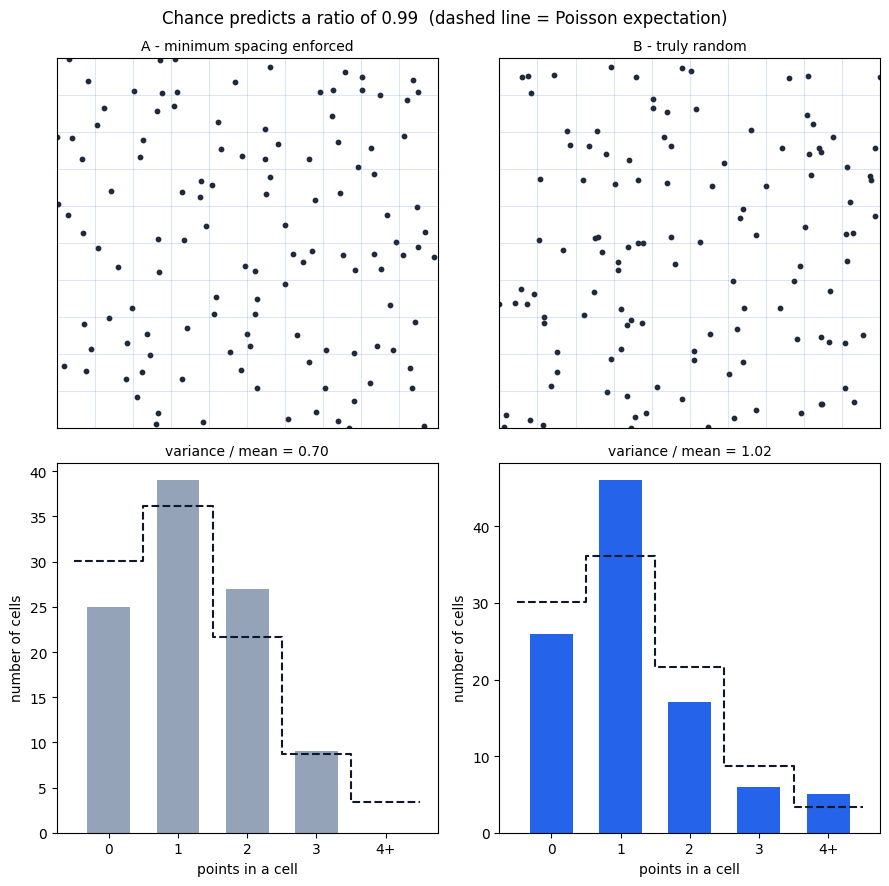

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
bins = list(range(MAX_BIN + 1))
labels = [str(b) for b in bins[:-1]] + [f"{bins[-1]}+"]

for col, (name, pts) in enumerate([("A - minimum spacing enforced", constrained_pattern),
                                   ("B - truly random", random_pattern)]):
    ax = axes[0][col]
    ax.scatter([p[0] for p in pts], [p[1] for p in pts], s=10, c="#1e293b")
    for g in range(K + 1):
        ax.axhline(g / K, lw=0.4, c="#2563eb", alpha=0.3)
        ax.axvline(g / K, lw=0.4, c="#2563eb", alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(name, fontsize=10)

    counts = cell_counts(pts, K)
    ax = axes[1][col]
    ax.bar(bins, count_histogram(counts, MAX_BIN),
           color="#2563eb" if col else "#94a3b8", width=0.62)
    ax.step([b - 0.5 for b in bins] + [bins[-1] + 0.5],
            expected + [expected[-1]], where="post", color="#0f172a", ls="--", lw=1.5)
    ax.set_xticks(bins); ax.set_xticklabels(labels)
    ax.set_xlabel("points in a cell"); ax.set_ylabel("number of cells")
    ax.set_title(f"variance / mean = {variance_mean_ratio(counts):.2f}", fontsize=10)

fig.suptitle(f"Chance predicts a ratio of {theory:.2f}  (dashed line = Poisson expectation)")
fig.tight_layout()
plt.show()

## What to look for

Both squares hold the same number of points, so both histograms have the same mean. What differs
is the spread.

The truly random pattern lands near the dashed line: it has **more empty cells and more crowded
cells** than the pattern that looks random. Forbidding close pairs removes the crowded cells, and
removing those removes the empty ones too, pulling the histogram in from both ends and dropping
the ratio well below chance.

That is the whole illusion. Evenness is a sign of a constraint, not of chance.

Change `MIN_SEP` and re-run: as it falls toward zero the constrained pattern's ratio climbs back
toward the chance value, and the two squares become genuinely hard to tell apart.

## Full opt-in API replication

The cells below run the exact published tasks across all published models (20 trials × 6 models), save every request and raw response, record provider, tokens, latency and cost, and resume from completed calls.

Paid calls are off by default. Add `OPENROUTER_API_KEY` to Colab Secrets, set `RUN_PAID_EVAL = True`, and choose an aggregate budget. The historical run cost about $1.10; current prices and routing can differ. Each request reserves a conservative worst-case amount before it is sent, so the configured aggregate budget cannot be exceeded.


In [ ]:
from pathlib import Path
import base64, json, re, urllib.request

RAW = "https://raw.githubusercontent.com/Alestainer/statistics-intuitions/main/"

def repo_bytes(relative):
    for path in (Path("../") / relative, Path(relative)):
        if path.exists(): return path.read_bytes()
    with urllib.request.urlopen(RAW + relative) as response: return response.read()

published = json.loads(repo_bytes("evals/results/which-map-is-random/gpt.json"))
JOBS = [{
    "id": row["trial_id"], "answer": row["truth"], "mirror_of": row.get("mirror_of"),
    "image": repo_bytes(f"evals/stimuli/which-map-is-random/{row['trial_id']}.png"),
} for row in published["trials"]]

BENCHMARK_ID = "which-map-is-random-v1"
RUN_PAID_EVAL = False
BUDGET_USD = 5.0
RERUN_DIR = Path("which-map-is-random-rerun")
MODEL_SPECS = {
    "openai/gpt-5.6-sol": {"input": 2.0, "output": 10.0},
    "google/gemini-3.7-flash": {"input": 0.75, "output": 3.75},
    "anthropic/claude-opus-5": {"input": 5.0, "output": 25.0},
    "anthropic/claude-sonnet-5": {"input": 2.0, "output": 10.0},
    "qwen/qwen3.8-max": {"input": 2.0, "output": 6.0},
    "moonshotai/kimi-k3": {"input": 3.0, "output": 15.0},
    "z-ai/glm-5.3-flash": {"input": 0.075, "output": 0.25},
}
MODELS_TO_RUN = [
    "openai/gpt-5.6-sol", "google/gemini-3.7-flash", "anthropic/claude-opus-5",
    "anthropic/claude-sonnet-5", "qwen/qwen3.8-max", "moonshotai/kimi-k3",
]
RUN_SETTINGS = {"max_tokens": 1600, "reasoning": {"max_tokens": 1024}}
SUITE_HASH = ""  # Set after the helper cell defines stable_hash.

QUESTION = "The image shows two squares of dots, labelled LEFT and RIGHT. Exactly one of them was generated by a truly random process; the other was generated by a different process. Which square was generated by the truly random process?\n\nAnswer with exactly one word on the first line: LEFT or RIGHT. Then one short sentence saying what made you choose it."

def parse_command(text):
    normalized = (text or "").strip().upper()
    first = normalized.splitlines()[0] if normalized else ""
    matches = re.findall(r"\b(?:LEFT|RIGHT)\b", first)
    if len(set(matches)) == 1: return matches[0], first in ("LEFT", "RIGHT")
    matches = re.findall(r"\b(?:LEFT|RIGHT)\b", normalized)
    return (matches[0] if len(set(matches)) == 1 else None), False

def build_payload(model, job):
    image = base64.b64encode(job["image"]).decode()
    messages = [{"role": "user", "content": [
        {"type": "text", "text": QUESTION},
        {"type": "image_url", "image_url": {"url": "data:image/png;base64," + image}},
    ]}]
    return openrouter_payload(model, messages, **RUN_SETTINGS)

def job_metadata(job):
    return {"trial_id": job["id"], "mirror_of": job.get("mirror_of"), "image_sha256": hashlib.sha256(job["image"]).hexdigest()}


In [ ]:
import hashlib, os, time, urllib.error
from datetime import datetime, timezone

OPENROUTER_ENDPOINT = "https://openrouter.ai/api/v1/chat/completions"
MAX_NOTEBOOK_BUDGET_USD = 25.0

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def stable_hash(value):
    encoded = json.dumps(value, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
    return hashlib.sha256(encoded.encode()).hexdigest()

def write_json(path, value):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False) + "\n")

def append_jsonl(path, value):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a") as handle:
        handle.write(json.dumps(value, ensure_ascii=False) + "\n")

def get_api_key():
    key = os.environ.get("OPENROUTER_API_KEY")
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("OPENROUTER_API_KEY")
        except Exception:
            key = None
    if not key:
        import getpass
        key = getpass.getpass("OpenRouter API key: ")
    return key

def openrouter_payload(model, messages, *, max_tokens, reasoning, temperature=None):
    spec = MODEL_SPECS[model]
    payload = {
        "model": model,
        "messages": messages,
        "max_tokens": max_tokens,
        "reasoning": reasoning,
        "usage": {"include": True},
        "provider": {
            "sort": "price", "allow_fallbacks": False, "require_parameters": False,
            "max_price": {"prompt": spec["input"], "completion": spec["output"]},
        },
    }
    if temperature is not None:
        payload["temperature"] = temperature
    return payload

def reserve_cost(payload):
    spec = MODEL_SPECS[payload["model"]]
    # UTF-8 bytes safely overestimate prompt tokens, including encoded images.
    prompt_ceiling = len(json.dumps(payload["messages"], ensure_ascii=False).encode()) + 256
    return prompt_ceiling * spec["input"] / 1_000_000 + payload["max_tokens"] * spec["output"] / 1_000_000

def send_openrouter(payload, api_key, timeout=240):
    request = urllib.request.Request(
        OPENROUTER_ENDPOINT,
        data=json.dumps(payload).encode(),
        method="POST",
        headers={
            "Authorization": f"Bearer {api_key}", "Content-Type": "application/json",
            "HTTP-Referer": "https://alestainer.com", "X-OpenRouter-Title": BENCHMARK_ID,
        },
    )
    started = time.perf_counter()
    try:
        with urllib.request.urlopen(request, timeout=timeout) as response:
            status, body = response.status, response.read().decode()
    except urllib.error.HTTPError as error:
        status, body = error.code, error.read().decode(errors="replace")
    try:
        parsed = json.loads(body)
    except json.JSONDecodeError:
        parsed = {"unparsed_body": body}
    return status, parsed, time.perf_counter() - started

def content_of(response):
    try:
        content = response["choices"][0]["message"]["content"]
    except (KeyError, IndexError, TypeError):
        return None
    return content if isinstance(content, str) else None

def usage_of(response):
    usage = response.get("usage") if isinstance(response.get("usage"), dict) else {}
    details = usage.get("completion_tokens_details")
    details = details if isinstance(details, dict) else {}
    cost = usage.get("cost")
    reasoning = details.get("reasoning_tokens")
    return {
        "prompt_tokens": usage.get("prompt_tokens"),
        "completion_tokens": usage.get("completion_tokens"),
        "reasoning_tokens": reasoning if isinstance(reasoning, (int, float)) else None,
        "cost_usd": cost if isinstance(cost, (int, float)) else None,
        "raw_usage": usage,
    }

def result_files():
    return sorted(RERUN_DIR.glob("models/*/calls/*/result.json"))

def load_existing():
    existing = {}
    for path in result_files():
        row = json.loads(path.read_text())
        if row.get("suite_hash") != SUITE_HASH:
            raise RuntimeError(f"Suite mismatch in {path}")
        existing[(row["model"], row["call_id"])] = row
    return existing

def prepare_run():
    if BUDGET_USD <= 0 or BUDGET_USD > MAX_NOTEBOOK_BUDGET_USD:
        raise ValueError(f"BUDGET_USD must be above $0 and at most ${MAX_NOTEBOOK_BUDGET_USD}")
    RERUN_DIR.mkdir(parents=True, exist_ok=True)
    config_path = RERUN_DIR / "config.json"
    config = {
        "created_at": utc_now(), "benchmark_id": BENCHMARK_ID,
        "models": MODELS_TO_RUN, "model_specs": MODEL_SPECS,
        "suite_hash": SUITE_HASH, "run_settings": RUN_SETTINGS,
        "approved_aggregate_budget_usd": BUDGET_USD,
    }
    if config_path.exists():
        prior = json.loads(config_path.read_text())
        for key in ("benchmark_id", "models", "model_specs", "suite_hash", "run_settings"):
            if prior.get(key) != config.get(key):
                raise RuntimeError(f"Resume configuration mismatch: {key}")
        if BUDGET_USD > float(prior["approved_aggregate_budget_usd"]):
            raise RuntimeError("A resume cannot raise the original budget; use a new output directory")
    else:
        write_json(config_path, config)
    existing = load_existing()
    if any(row.get("cost_usd") is None for row in existing.values()):
        raise RuntimeError("Cannot resume safely: a completed call is missing reported cost")
    return get_api_key(), existing, sum(float(row["cost_usd"]) for row in existing.values())

def save_call(*, model, call_id, payload, expected, metadata, existing, api_key, spent):
    key = (model, call_id)
    if key in existing:
        return existing[key], spent, None
    reservation = reserve_cost(payload)
    if spent + reservation > BUDGET_USD + 1e-12:
        return None, spent, f"STOP budget: spent ${spent:.6f}; next call reserves ${reservation:.6f}; cap ${BUDGET_USD:.6f}"
    call_dir = RERUN_DIR / "models" / model.replace("/", "--") / "calls" / call_id
    write_json(call_dir / "request.json", payload)
    status, response, latency = send_openrouter(payload, api_key)
    write_json(call_dir / "raw-response.json", response)
    append_jsonl(RERUN_DIR / "raw-responses.jsonl", {
        "model": model, "call_id": call_id, "http_status": status, "response": response,
    })
    if status < 200 or status >= 300 or "error" in response:
        write_json(call_dir / "error.json", {
            "model": model, "call_id": call_id, "http_status": status,
            "latency_seconds": latency, "response": response, "recorded_at": utc_now(),
        })
        return None, spent, f"STOP API error on {model}/{call_id}: HTTP {status}; rerun to resume"
    raw = content_of(response)
    parsed, strict = parse_command(raw)
    usage = usage_of(response)
    result = {
        "model": model, "returned_model": response.get("model"),
        "provider": response.get("provider"), "call_id": call_id,
        "suite_hash": SUITE_HASH, "expected": expected, "parsed": parsed,
        "strictly_formatted": strict, "correct": parsed == expected,
        "raw_content": raw, "latency_seconds": latency, "recorded_at": utc_now(),
        **metadata, **usage,
    }
    write_json(call_dir / "result.json", result)
    existing[key] = result
    if usage["cost_usd"] is None:
        return result, spent, "STOP accounting: response has no reported cost; rerun to resume"
    spent += float(usage["cost_usd"])
    return result, spent, None


In [ ]:
SUITE_HASH = stable_hash({"benchmark": BENCHMARK_ID, "jobs": [(j["id"], j["answer"], hashlib.sha256(j["image"]).hexdigest()) for j in JOBS], "models": MODELS_TO_RUN, "settings": RUN_SETTINGS})
def run_full_suite():
    api_key, existing, spent = prepare_run()
    stop = None
    total = len(MODELS_TO_RUN) * len(JOBS)
    for order, model in enumerate(MODELS_TO_RUN):
        for job_index, job in enumerate(JOBS):
            call_number = order * len(JOBS) + job_index + 1
            call_id = job["id"]
            if (model, call_id) not in existing:
                print(f"run {call_number:03d}/{total} {model}/{call_id}")
            payload = build_payload(model, job)
            _, spent, stop = save_call(
                model=model, call_id=call_id, payload=payload, expected=job["answer"],
                metadata=job_metadata(job), existing=existing, api_key=api_key, spent=spent,
            )
            if stop:
                print(stop)
                break
        if stop:
            break
    summary = {
        "updated_at": utc_now(), "completed_calls": len(existing), "expected_calls": total,
        "reported_cost_usd": sum(float(r["cost_usd"]) for r in existing.values() if r.get("cost_usd") is not None),
        "correct_calls": sum(r.get("correct") is True for r in existing.values()),
        "missing_cost_calls": sum(r.get("cost_usd") is None for r in existing.values()),
    }
    write_json(RERUN_DIR / "summary.json", summary)
    return summary

print(f"Exact tasks: {len(JOBS)}; selected models: {len(MODELS_TO_RUN)}; planned calls: {len(JOBS) * len(MODELS_TO_RUN)}")
largest_reservation = max(reserve_cost(build_payload(model, job)) for model in MODELS_TO_RUN for job in JOBS)
print(f"Largest conservative single-call reservation: ${largest_reservation:.4f}")
if RUN_PAID_EVAL:
    print(json.dumps(run_full_suite(), indent=2))
else:
    print("DRY RUN ONLY — set RUN_PAID_EVAL = True to send requests")


## Analyze your rerun


In [ ]:
import pandas as pd

rerun_rows = [json.loads(path.read_text()) for path in result_files()]
if not rerun_rows:
    print("No rerun results yet.")
else:
    rerun = pd.DataFrame(rerun_rows)
    display(rerun.groupby("model").agg(calls=("call_id", "size"), correct=("correct", "sum"), cost_usd=("cost_usd", "sum")))
